In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [4]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [5]:
image_cut = image[55:175, 0:1890]
image_error_cut = image_error[55:175, 0:1890]

Text(0.5, 0, 'wavelength')

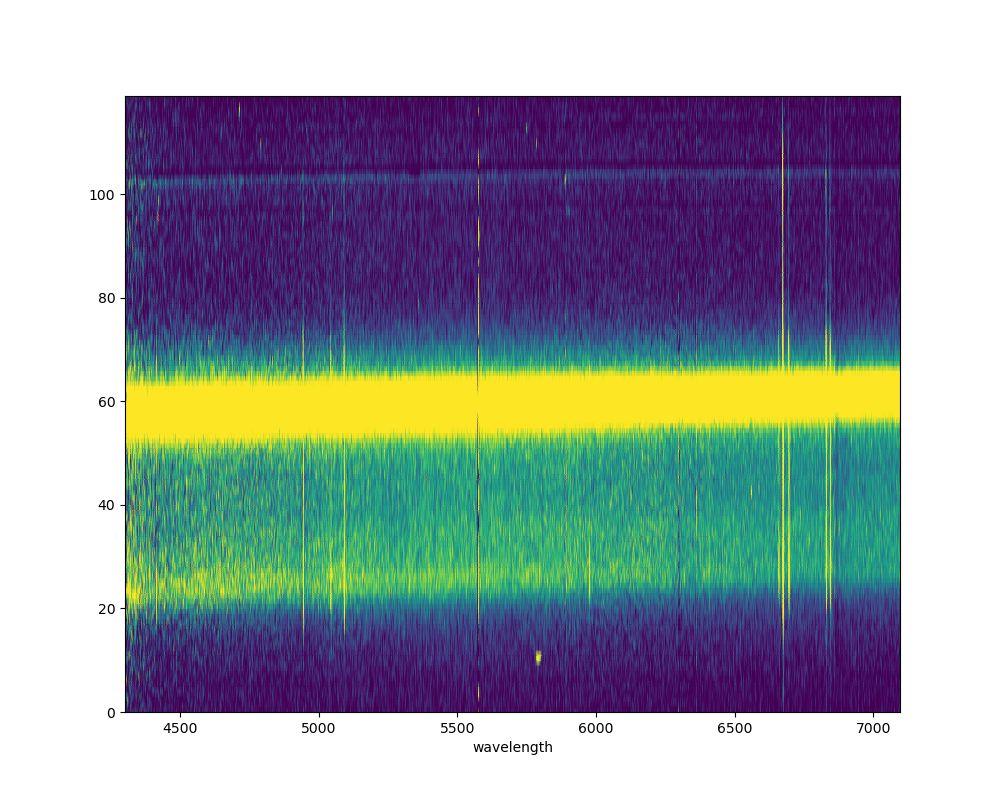

In [6]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [7]:
z = 0.01736
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/PSF/Real_seeing_UGC409.txt")
sigmas = seeing / 2.35
print(sigmas)

[2.18004842 2.5199744  2.17810166 2.16914413 2.48282011 2.19531915]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

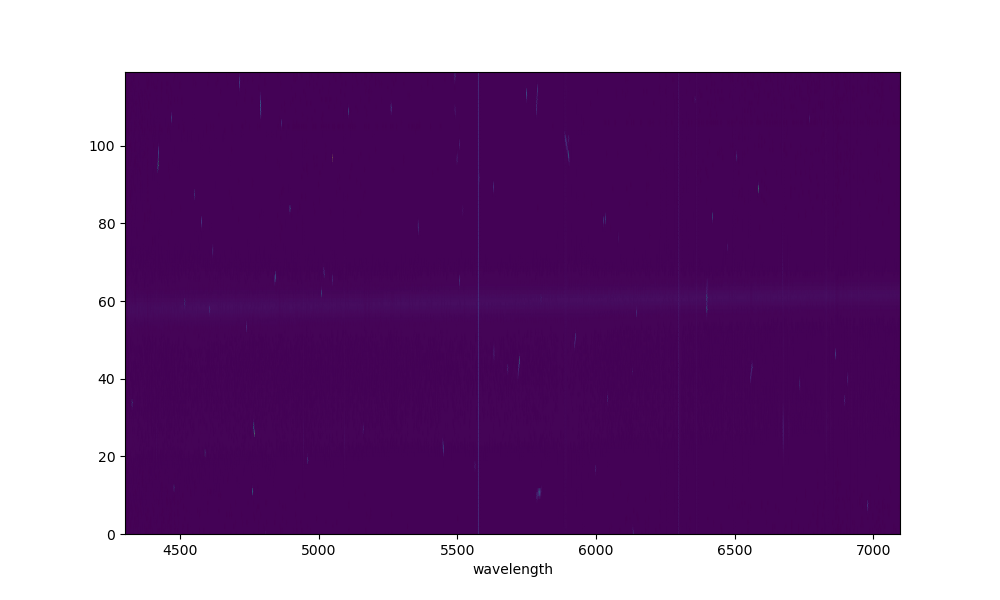

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:175, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

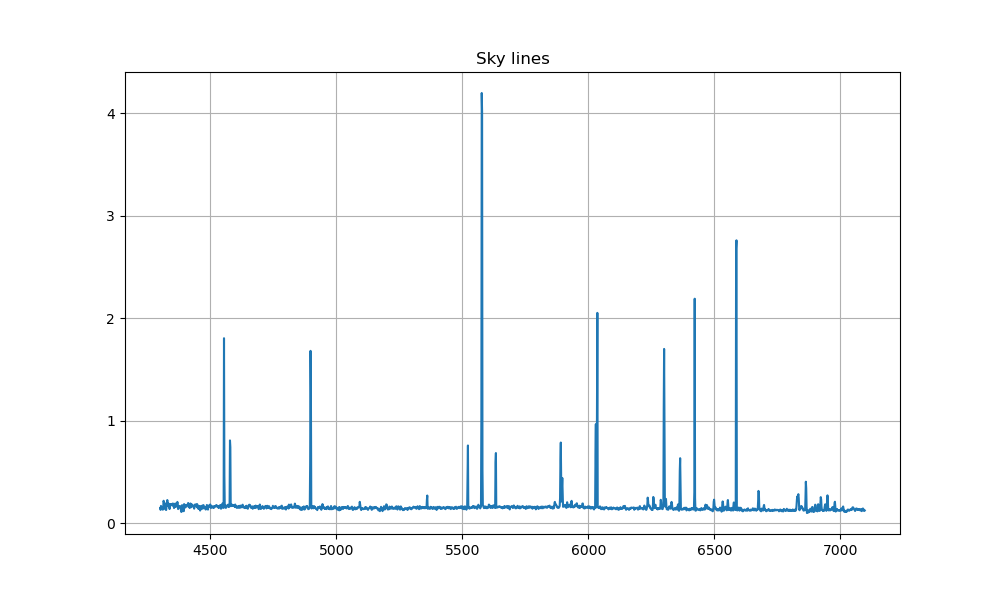

In [9]:
mask_sky = (y > 80)*(y < 90)
mask_wv = wv > 0
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

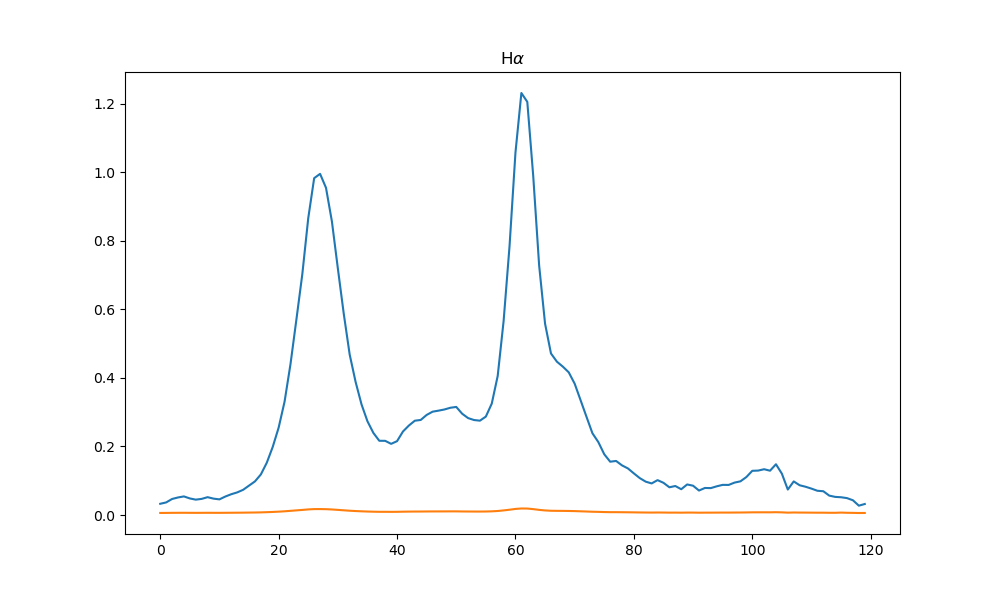

In [11]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [19]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.4)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.4)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 30),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (59, 65),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 48),   # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 70),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (102, 103),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3038.015351061972
differential_evolution step 2: f(x)= 3038.015351061972
differential_evolution step 3: f(x)= 3038.015351061972
differential_evolution step 4: f(x)= 3038.015351061972
differential_evolution step 5: f(x)= 2076.6147781532563
differential_evolution step 6: f(x)= 649.9789755290328
differential_evolution step 7: f(x)= 649.9789755290328
differential_evolution step 8: f(x)= 649.9789755290328
differential_evolution step 9: f(x)= 649.9789755290328
differential_evolution step 10: f(x)= 508.40855841635977
differential_evolution step 11: f(x)= 508.40855841635977
differential_evolution step 12: f(x)= 508.40855841635977
differential_evolution step 13: f(x)= 508.40855841635977
differential_evolution step 14: f(x)= 508.40855841635977
differential_evolution step 15: f(x)= 245.0115555752252
differential_evolution step 16: f(x)= 245.0115555752252
differential_evolution step 17: f(x)= 191.68491247797826
differential_evolution step 18: f(x)= 191.68491247

In [ ]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [22]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1350, r_e=9.7307, n=1.5454, x_0=27.0221
Sérsic 2: I_e=0.1031, r_e=1.8375, n=3.4224, x_0=61.2111
Sérsic 3: I_e=0.1375, r_e=7.7812, n=0.4786, x_0=47.9541
Sérsic 4: I_e=0.0663, r_e=14.1362, n=1.2243, x_0=68.1128
Sérsic 5: I_e=0.0312, r_e=17.0264, n=0.8848, x_0=102.0917
[1.65736982e-02 7.57843916e-01 9.65542121e-02 5.74390770e-02
 1.80937294e+00 1.66355049e+01 5.11182299e+01 8.33589224e-02
 2.77158010e-02 9.23774577e-01 1.08713674e-01 1.00062674e+00
 2.45579439e-02 4.29542384e+00 2.54634061e-01 4.81125422e-01
 1.57375455e-02 8.39586446e+00 3.18415677e-01 6.75279190e-01]
0.19932278974356696


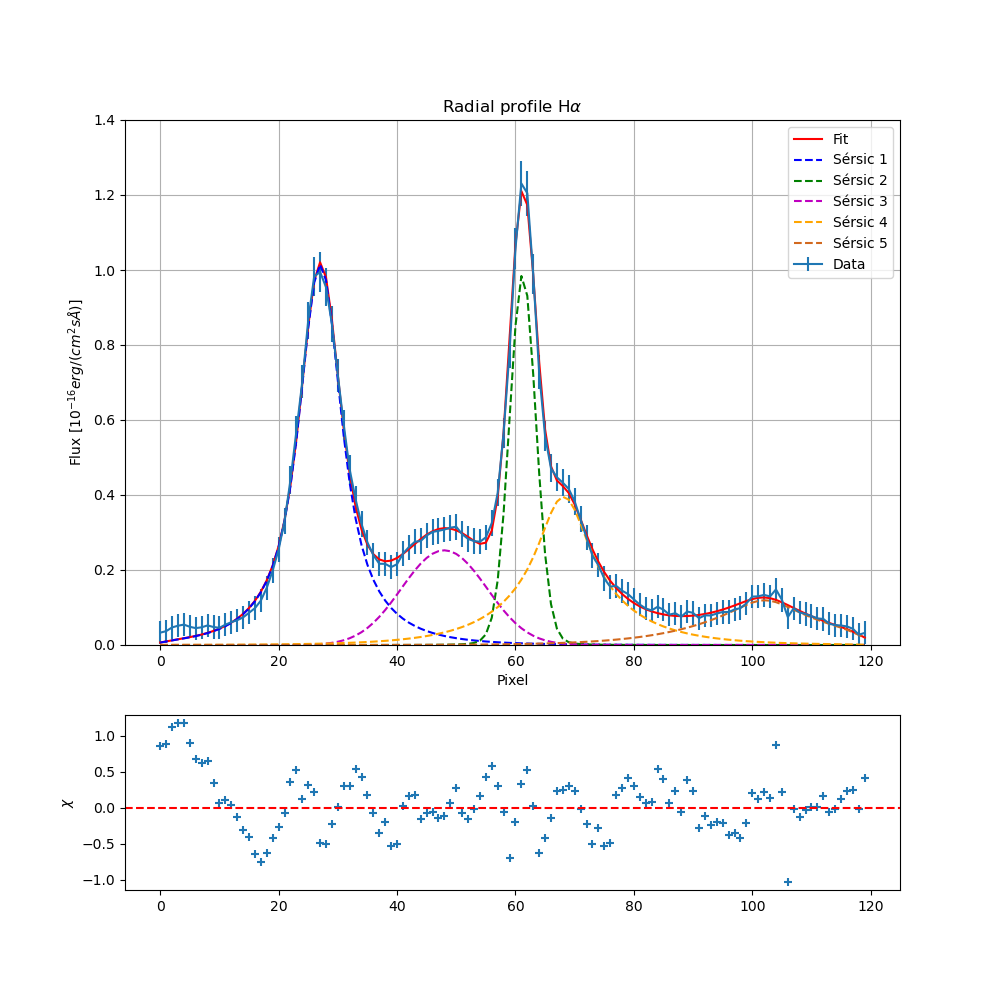

In [23]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [64]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: posizione da 0 a 100

    (0, 10),
    (5, 20),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),   # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 20),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

bounds_OIII = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 30),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (59, 65),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (5, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 48),   # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 70),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 10),
    (0.1, 10),
    (102, 103),
]

## H$\beta$

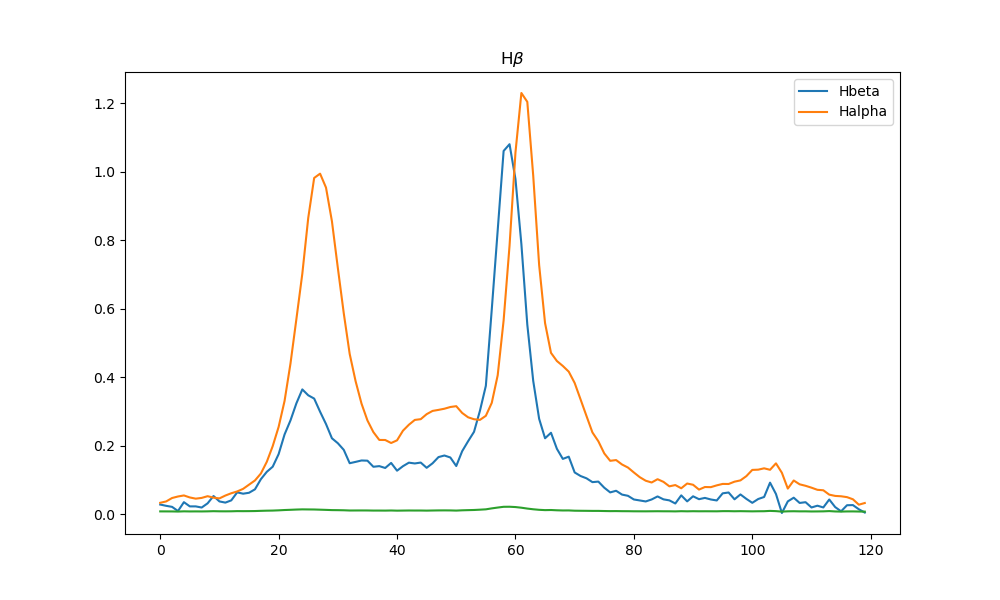

In [59]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 120, 1)
plt.plot(x_axes, radial_profile_HB, label ='Hbeta')
plt.plot(x_axes, radial_profile_HA, label = 'Halpha')
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')
plt.legend()

In [60]:
# Bounds:
bounds = bounds_OIII

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 30640.637793955684
differential_evolution step 2: f(x)= 28564.028736178057
differential_evolution step 3: f(x)= 7812.023400302298
differential_evolution step 4: f(x)= 2369.46531893511
differential_evolution step 5: f(x)= 1130.9888159730938
differential_evolution step 6: f(x)= 1130.9888159730938
differential_evolution step 7: f(x)= 1130.9888159730938
differential_evolution step 8: f(x)= 1130.9888159730938
differential_evolution step 9: f(x)= 1130.9888159730938
differential_evolution step 10: f(x)= 511.77493861372614
differential_evolution step 11: f(x)= 511.77493861372614
differential_evolution step 12: f(x)= 511.77493861372614
differential_evolution step 13: f(x)= 511.77493861372614
differential_evolution step 14: f(x)= 511.77493861372614
differential_evolution step 15: f(x)= 511.77493861372614
differential_evolution step 16: f(x)= 511.77493861372614
differential_evolution step 17: f(x)= 511.77493861372614
differential_evolution step 18: f(x)= 511.7

Sérsic 1: I_e=0.0621, r_e=5.8232, n=1.3349, x_0=24.2991
Sérsic 2: I_e=0.0270, r_e=1.6046, n=5.8567, x_0=59.0094
Sérsic 3: I_e=0.0941, r_e=19.9782, n=0.4144, x_0=47.8913
Sérsic 4: I_e=0.7780, r_e=0.1229, n=0.8383, x_0=68.0857
Sérsic 5: I_e=0.0358, r_e=9.9071, n=0.2968, x_0=102.0033


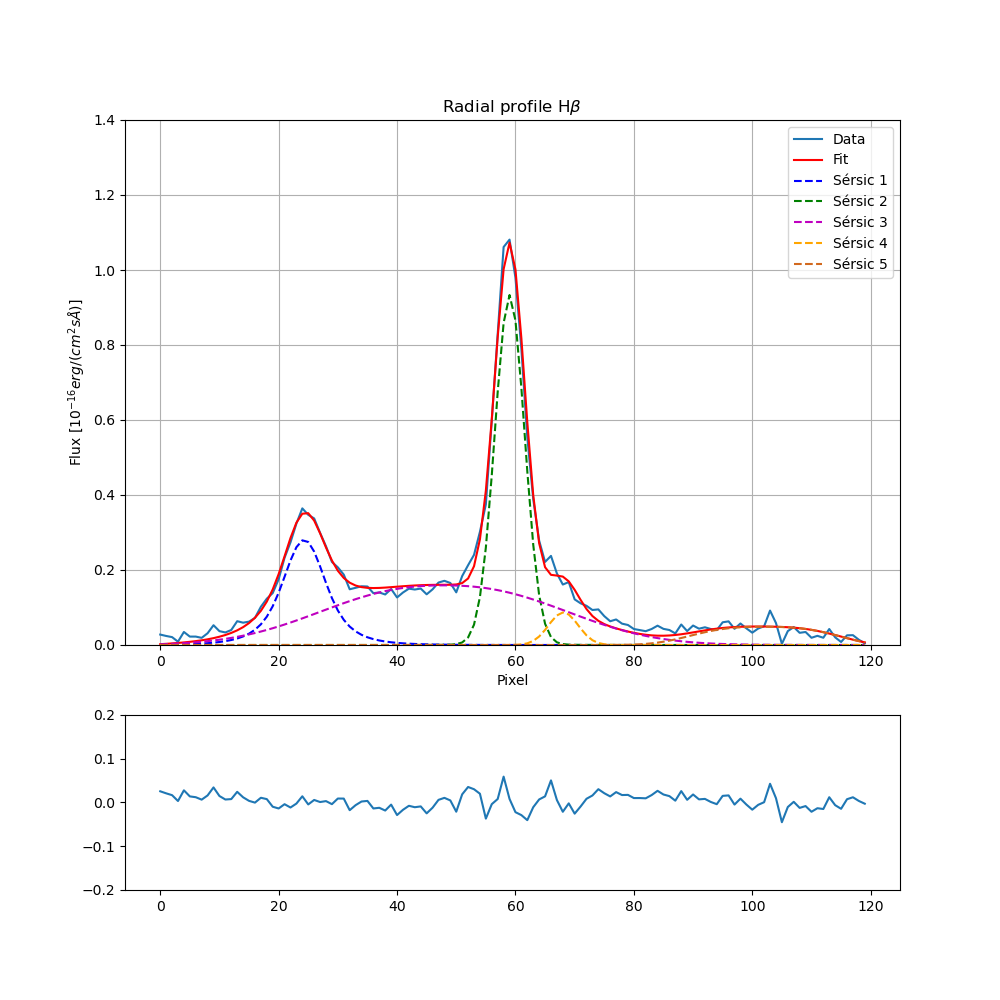

In [61]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [67]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0122, r_e=18.0080, n=2.6076, x_0=24.4110
Sérsic 2: I_e=0.0086, r_e=8.2556, n=5.1001, x_0=59.0090
Sérsic 3: I_e=0.0872, r_e=20.0000, n=0.3960, x_0=48.0000
Sérsic 4: I_e=0.5625, r_e=0.1751, n=0.7183, x_0=68.0002
Sérsic 5: I_e=0.0346, r_e=9.9996, n=0.3129, x_0=102.0000
[3.13331682e-02 4.74566751e+01 1.74411063e+00 1.79078379e-01
 1.15693435e+00 6.27446249e+02 2.91117215e+02 4.23501438e-03
 3.12116239e-02 5.92099522e+00 1.93936873e-01 1.16750171e+01
 2.04405746e+04 1.53893005e+02 4.32967309e+04 2.32792116e+00
 1.57282019e-02 2.30527481e+00 2.36812561e-01 1.51098982e+00]
0.29397210049410133


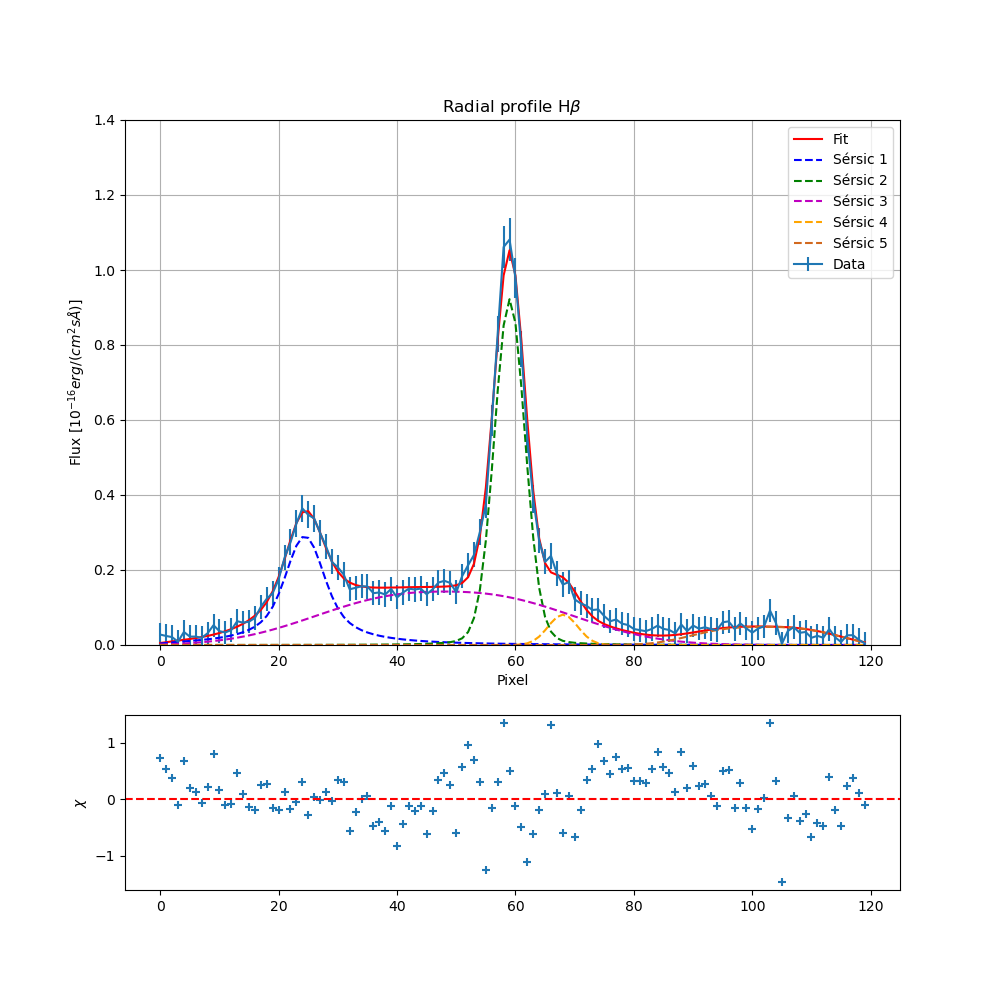

In [68]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

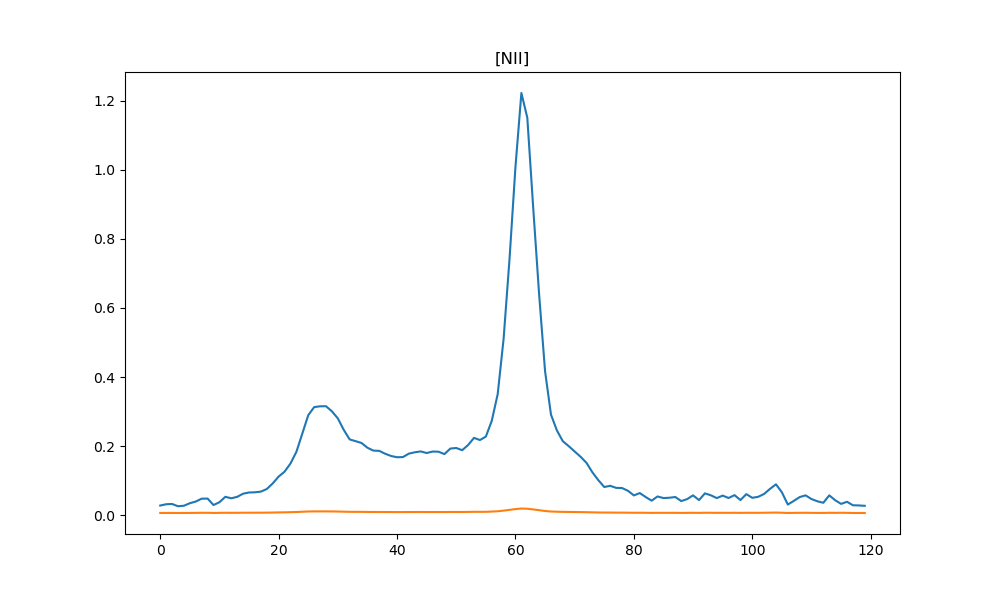

In [69]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [70]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 12883.214103559267
differential_evolution step 2: f(x)= 12883.214103559267
differential_evolution step 3: f(x)= 12883.214103559267
differential_evolution step 4: f(x)= 12883.214103559267
differential_evolution step 5: f(x)= 12883.214103559267
differential_evolution step 6: f(x)= 12883.214103559267
differential_evolution step 7: f(x)= 12883.214103559267
differential_evolution step 8: f(x)= 12883.214103559267
differential_evolution step 9: f(x)= 12883.214103559267
differential_evolution step 10: f(x)= 12883.214103559267
differential_evolution step 11: f(x)= 12883.214103559267
differential_evolution step 12: f(x)= 6802.8400501418655
differential_evolution step 13: f(x)= 6802.8400501418655
differential_evolution step 14: f(x)= 6802.8400501418655
differential_evolution step 15: f(x)= 6802.8400501418655
differential_evolution step 16: f(x)= 5962.191332842403
differential_evolution step 17: f(x)= 5962.191332842403
differential_evolution step 18: f(x)= 5962

Sérsic 1: I_e=0.0216, r_e=12.8127, n=1.7870, x_0=27.1944
Sérsic 2: I_e=0.0235, r_e=5.2802, n=4.3934, x_0=61.2706
Sérsic 3: I_e=0.0791, r_e=24.9131, n=0.5774, x_0=49.2028
Sérsic 4: I_e=0.0306, r_e=2.1190, n=1.4246, x_0=69.0911
Sérsic 5: I_e=0.0361, r_e=11.8781, n=0.3035, x_0=104.0350


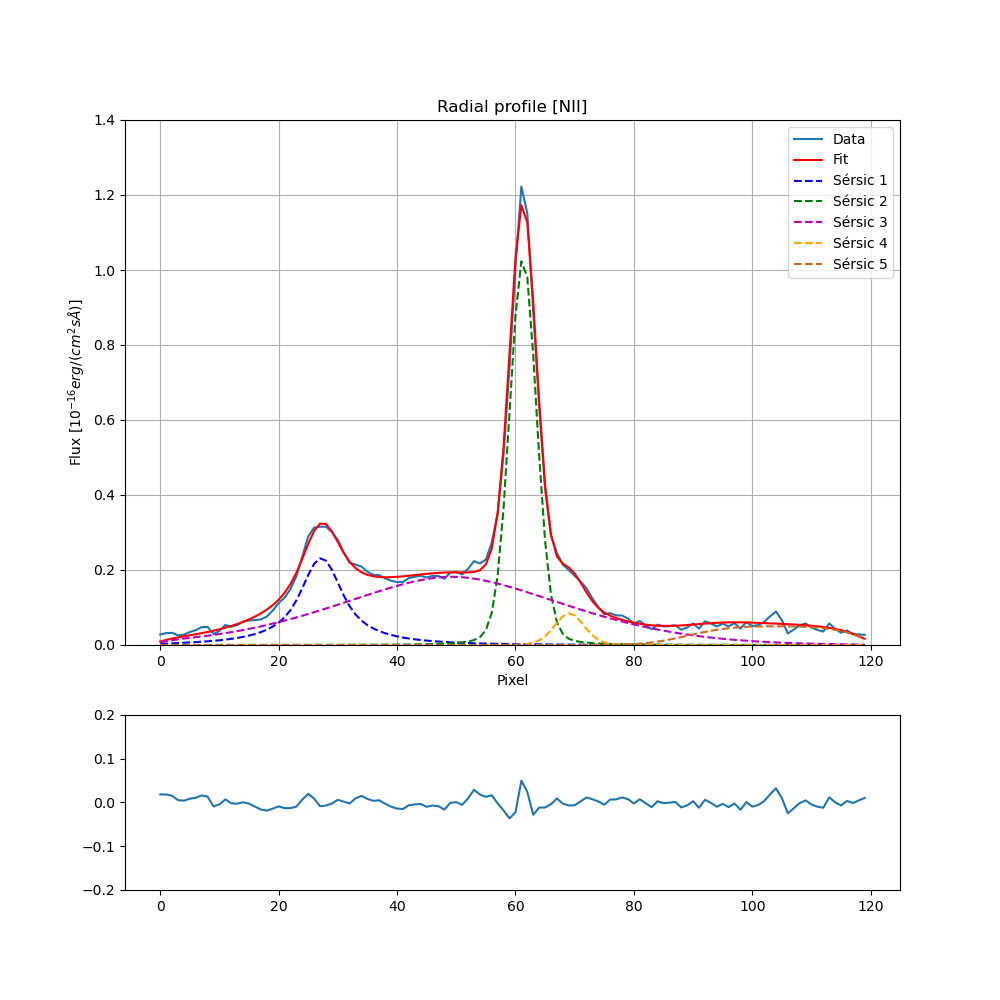

In [71]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [72]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0220, r_e=14.0547, n=1.7949, x_0=27.3547
Sérsic 2: I_e=0.0224, r_e=4.5477, n=4.4407, x_0=61.2706
Sérsic 3: I_e=0.0716, r_e=26.2521, n=0.6460, x_0=51.3476
Sérsic 4: I_e=0.0439, r_e=1.9291, n=0.8878, x_0=69.0286
Sérsic 5: I_e=0.0320, r_e=11.1224, n=0.3169, x_0=105.9486
[4.02307774e-02 2.80185033e+01 1.24821245e+00 1.36948543e-01
 3.31599521e+00 3.75756669e+02 3.37665956e+02 7.05981072e-03
 4.68806547e-02 6.08788155e+00 2.33087308e-01 1.50195599e+01
 3.16438594e-01 7.28079194e+00 6.62387877e+00 4.53674766e-01
 7.47813789e-03 2.74826281e+00 1.70657328e-01 2.07175659e+00]
0.12746017136718923


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10348\769716348.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10348\769716348.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


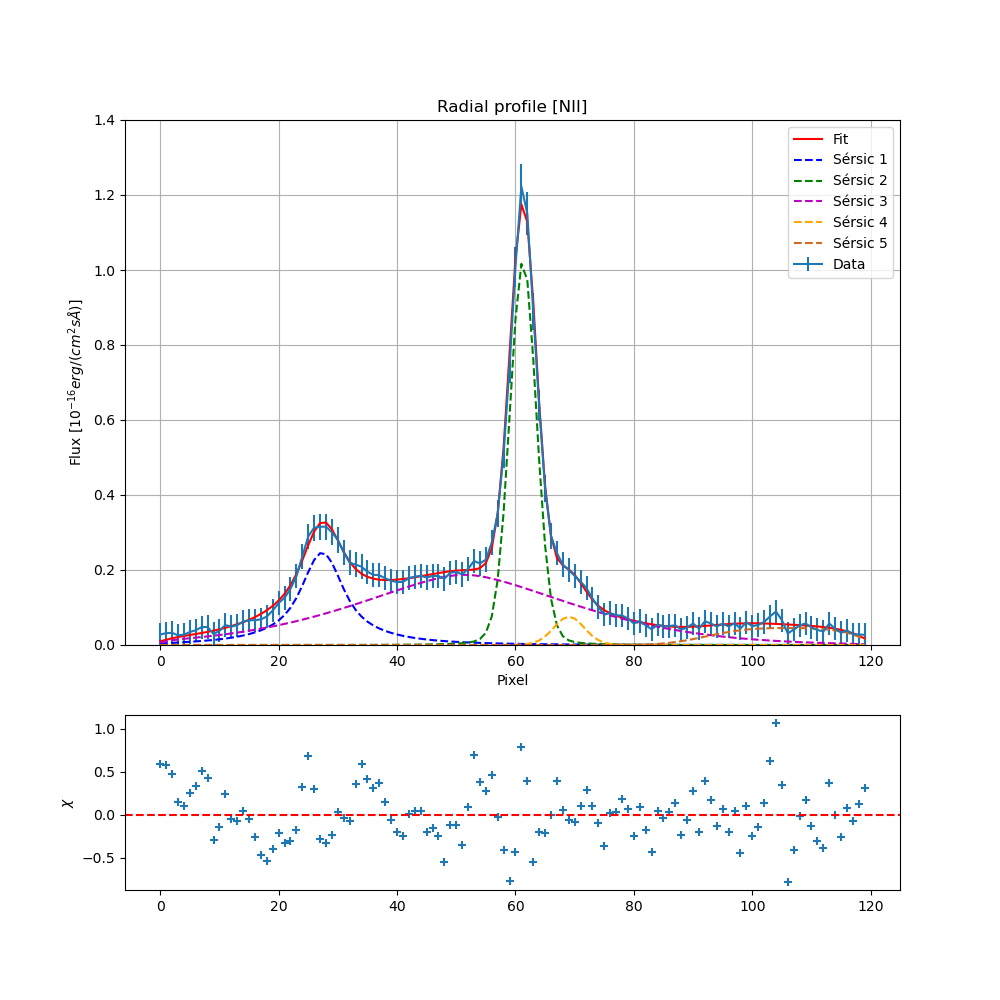

In [73]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

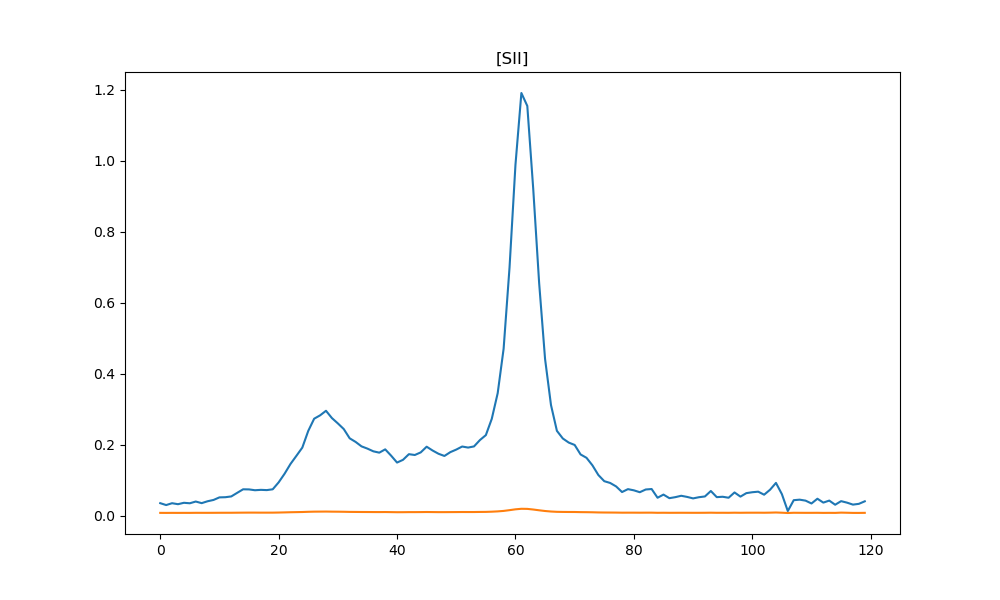

In [38]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [39]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 30460.241281451188
differential_evolution step 2: f(x)= 30460.241281451188
differential_evolution step 3: f(x)= 10598.562196363091
differential_evolution step 4: f(x)= 7131.954701260667
differential_evolution step 5: f(x)= 2073.304020007878
differential_evolution step 6: f(x)= 2073.304020007878
differential_evolution step 7: f(x)= 1302.3674894921874
differential_evolution step 8: f(x)= 1302.3674894921874
differential_evolution step 9: f(x)= 1302.3674894921874
differential_evolution step 10: f(x)= 1302.3674894921874
differential_evolution step 11: f(x)= 251.3682467707067
differential_evolution step 12: f(x)= 251.3682467707067
differential_evolution step 13: f(x)= 251.3682467707067
differential_evolution step 14: f(x)= 251.3682467707067
differential_evolution step 15: f(x)= 251.3682467707067
differential_evolution step 16: f(x)= 251.3682467707067
differential_evolution step 17: f(x)= 251.3682467707067
differential_evolution step 18: f(x)= 251.36824677

Sérsic 1: I_e=0.0581, r_e=5.3954, n=0.9765, x_0=27.6494
Sérsic 2: I_e=0.3421, r_e=1.1047, n=2.3980, x_0=61.4194
Sérsic 3: I_e=0.0680, r_e=31.4477, n=0.6956, x_0=50.5332
Sérsic 4: I_e=0.1750, r_e=0.8731, n=0.2352, x_0=69.5434
Sérsic 5: I_e=0.0295, r_e=9.8898, n=0.1855, x_0=104.6712


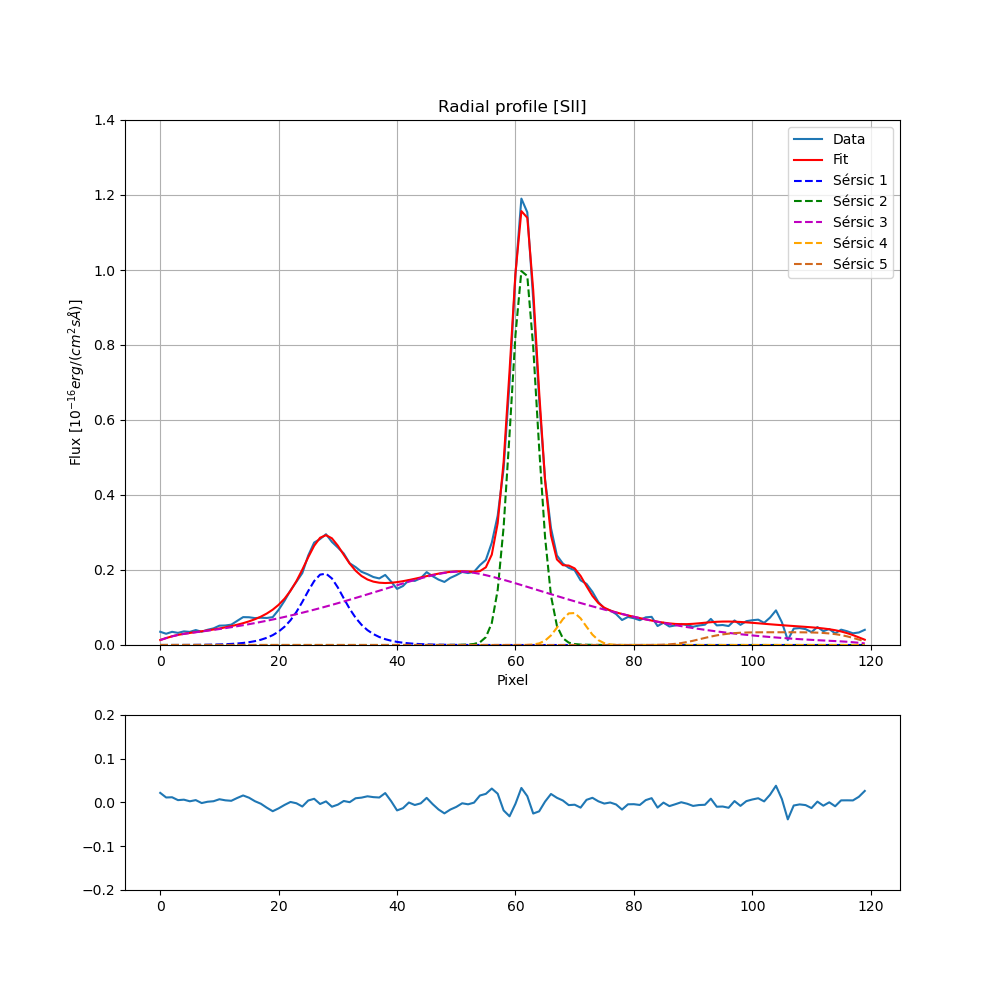

In [40]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [41]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0556, r_e=5.6501, n=0.9893, x_0=27.8402
Sérsic 2: I_e=0.0751, r_e=2.7340, n=3.4923, x_0=61.4194
Sérsic 3: I_e=0.0647, r_e=32.4238, n=0.7033, x_0=49.9633
Sérsic 4: I_e=0.0999, r_e=1.8742, n=0.1167, x_0=69.5815
Sérsic 5: I_e=0.0292, r_e=9.9665, n=0.1720, x_0=104.6712
[2.71929170e-02 2.30786813e+00 3.73018348e-01 1.69332155e-01
 9.89144593e-01 1.74299528e+01 6.04737868e+01 1.77438537e-02
 1.17397465e-02 3.82280624e+00 1.56777135e-01 3.21877174e+00
 1.33051269e+00 5.64062898e+01 9.79368005e+00 4.32293462e-01
 6.38000411e-03 1.22797344e+00 1.84435048e-01 1.31978019e+00]
0.14480020618364808


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10348\769716348.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


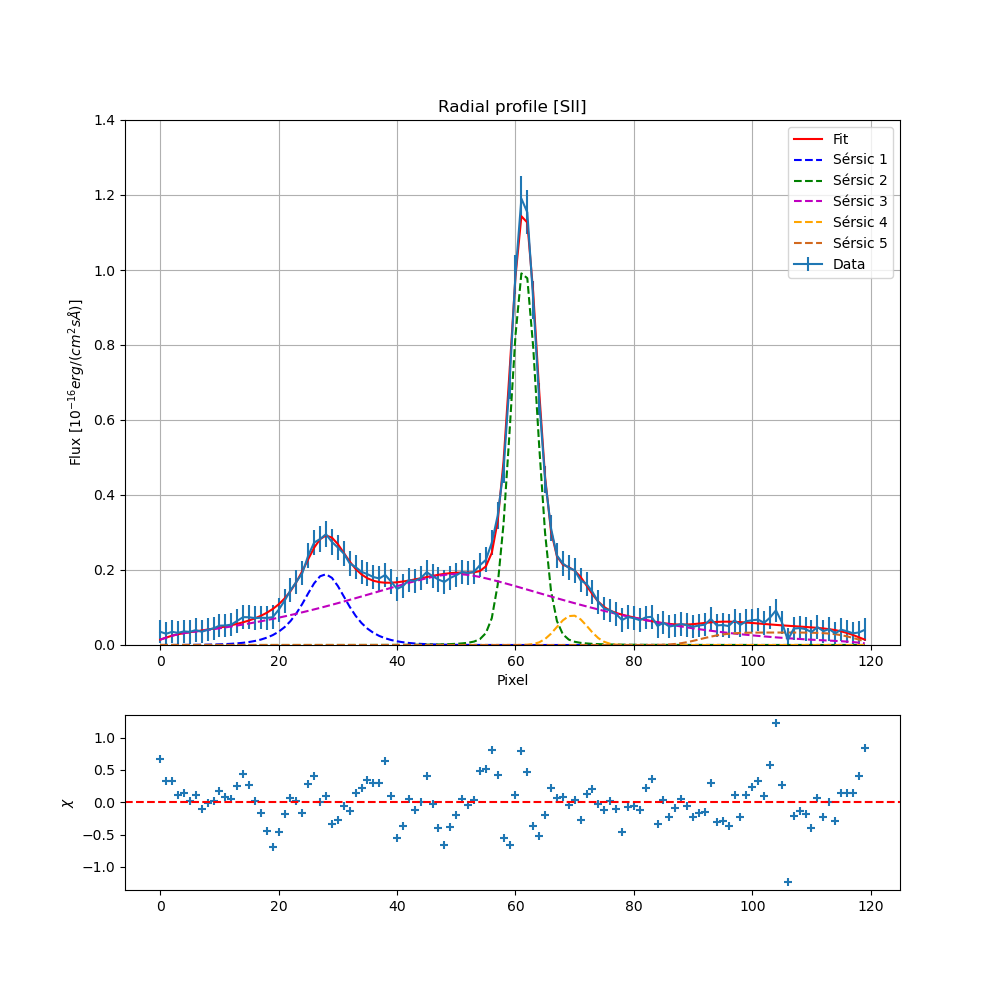

In [42]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

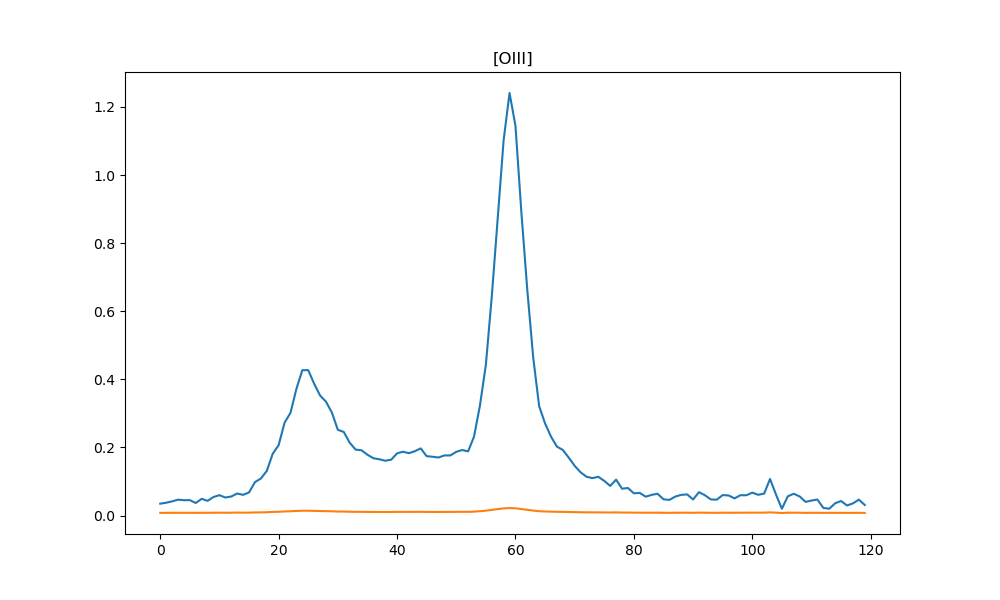

In [43]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [44]:
# Bounds:
bounds = bounds_OIII
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 34769.36500056385
differential_evolution step 2: f(x)= 9956.652837269488
differential_evolution step 3: f(x)= 1746.2236674419566
differential_evolution step 4: f(x)= 1746.2236674419566
differential_evolution step 5: f(x)= 1746.2236674419566
differential_evolution step 6: f(x)= 1746.2236674419566
differential_evolution step 7: f(x)= 1746.2236674419566
differential_evolution step 8: f(x)= 1746.2236674419566
differential_evolution step 9: f(x)= 1746.2236674419566
differential_evolution step 10: f(x)= 120.83239879636689
differential_evolution step 11: f(x)= 120.83239879636689
differential_evolution step 12: f(x)= 120.83239879636689
differential_evolution step 13: f(x)= 120.83239879636689
differential_evolution step 14: f(x)= 120.83239879636689
differential_evolution step 15: f(x)= 120.83239879636689
differential_evolution step 16: f(x)= 114.13087692246538
differential_evolution step 17: f(x)= 37.0722350420989
differential_evolution step 18: f(x)= 11.546

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10348\769716348.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.1678, r_e=3.7266, n=0.6200, x_0=25.0847
Sérsic 2: I_e=2.6071, r_e=0.5276, n=0.6329, x_0=59.0895
Sérsic 3: I_e=0.0466, r_e=47.3891, n=0.8898, x_0=47.3603
Sérsic 4: I_e=5.6645, r_e=0.0074, n=9.1679, x_0=68.0000
Sérsic 5: I_e=1.1889, r_e=0.0260, n=5.0814, x_0=102.3240
Chi quadro minimo: 0.029763705981804403
False


Sérsic 1: I_e=0.1678, r_e=3.7266, n=0.6200, x_0=25.0847
Sérsic 2: I_e=2.6071, r_e=0.5276, n=0.6329, x_0=59.0895
Sérsic 3: I_e=0.0466, r_e=47.3891, n=0.8898, x_0=47.3603
Sérsic 4: I_e=5.6645, r_e=0.0074, n=9.1679, x_0=68.0000
Sérsic 5: I_e=1.1889, r_e=0.0260, n=5.0814, x_0=102.3240


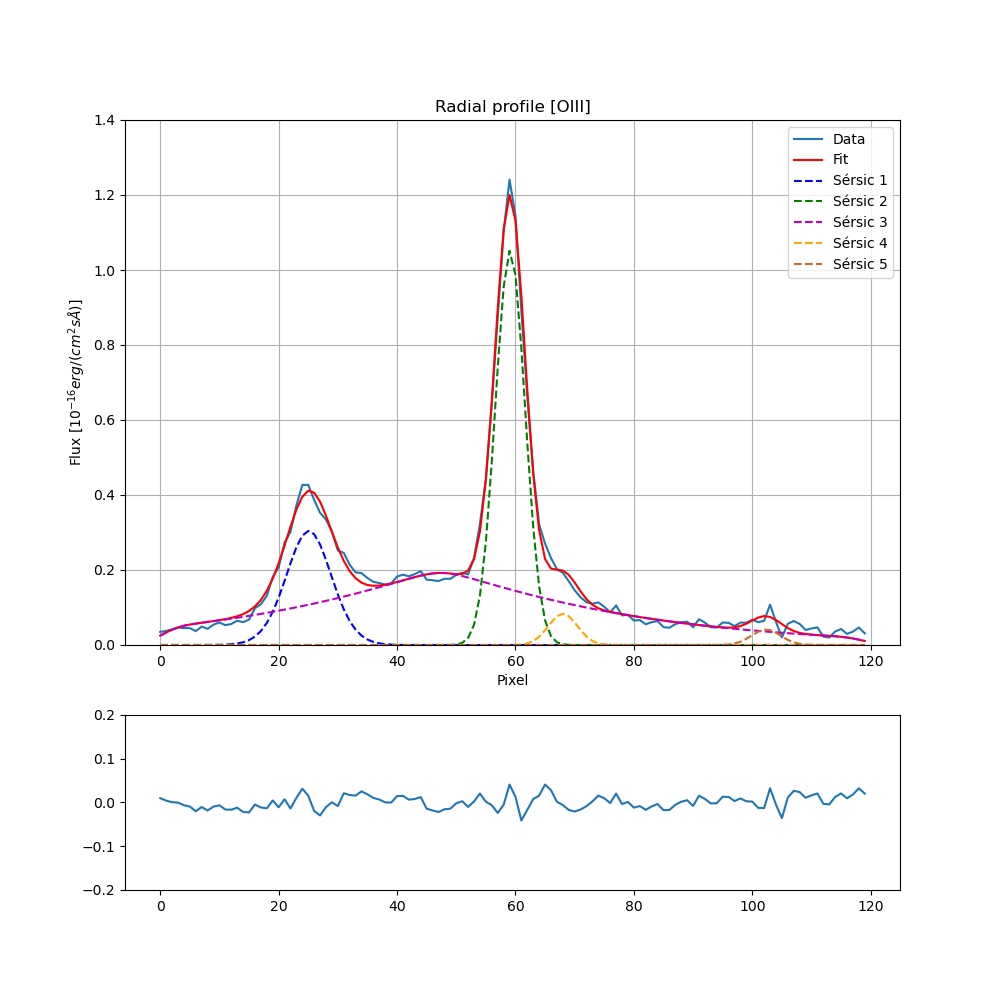

In [45]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [46]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1536, r_e=3.9502, n=0.6805, x_0=25.1431
Sérsic 2: I_e=0.4865, r_e=1.0492, n=2.1544, x_0=59.0983
Sérsic 3: I_e=0.0445, r_e=48.5716, n=0.9080, x_0=47.4111
Sérsic 4: I_e=5.6345, r_e=0.0073, n=9.1131, x_0=68.0000
Sérsic 5: I_e=1.1728, r_e=0.0224, n=5.2032, x_0=102.3270
[4.80930402e-02 6.33390461e-01 2.53168631e-01 1.24989313e-01
 3.28498885e+00 3.15465503e+00 1.05417722e+01 4.39683900e-02
 1.21514852e-02 9.41462383e+00 1.60320136e-01 1.24196485e+00
 1.90151222e+06 1.19919142e+03 6.45966597e+05 8.33315892e+01
 2.45031623e+05 2.67106056e+03 5.01580657e+05 1.44967928e+02]
0.24819992852392928


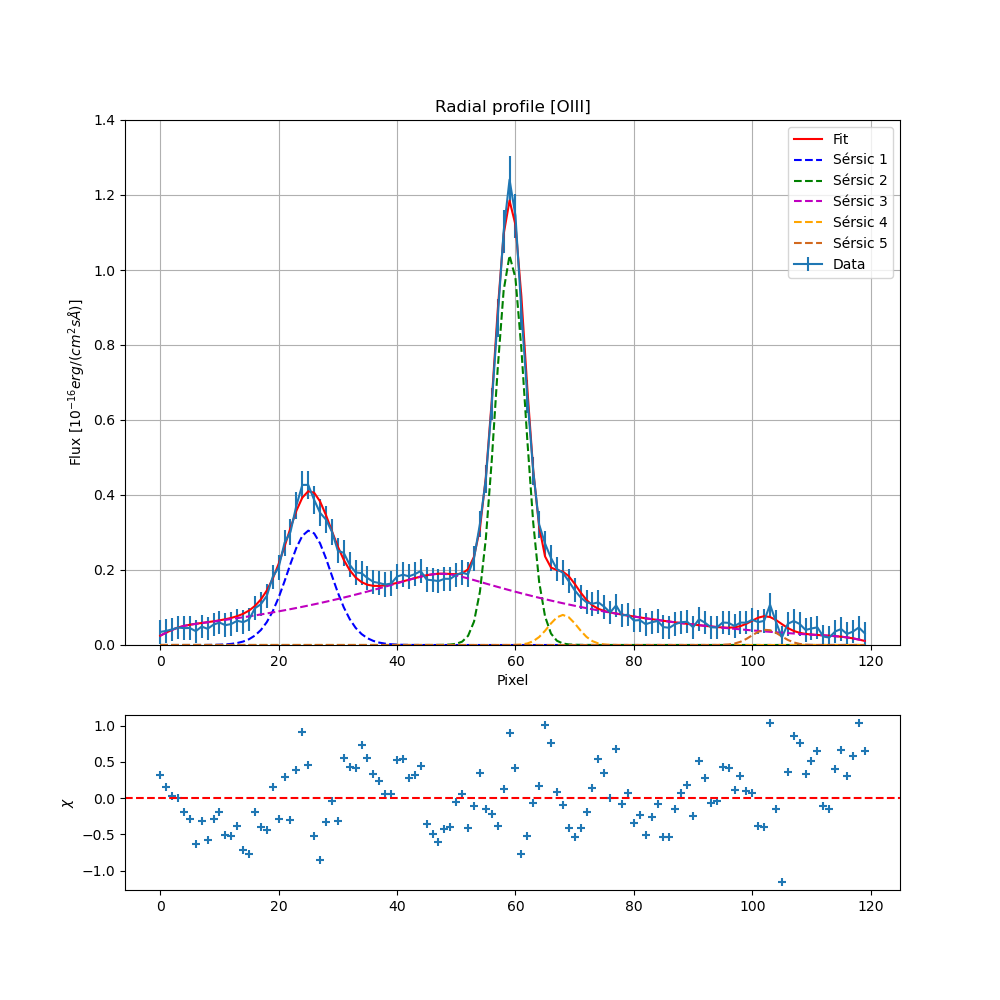

In [47]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [55]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

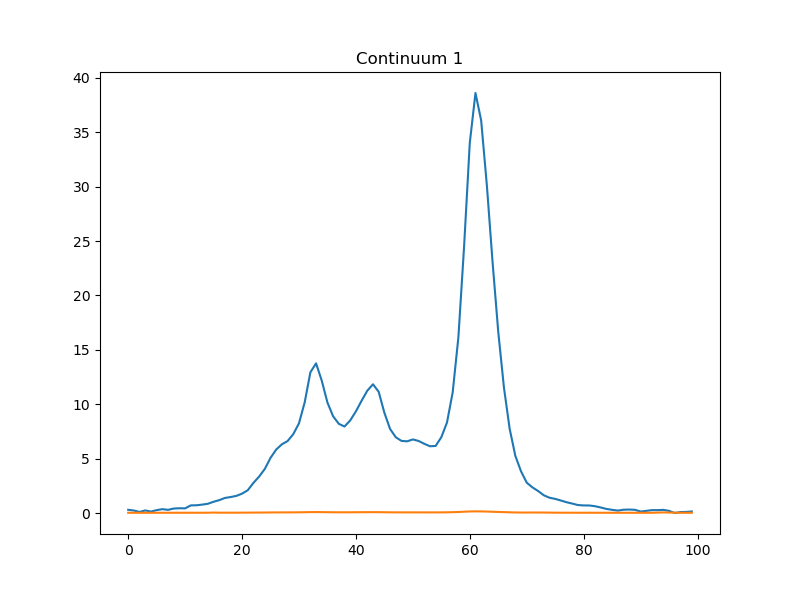

In [56]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [57]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3690.9908545962703
differential_evolution step 2: f(x)= 3050.220389991589
differential_evolution step 3: f(x)= 2855.430634180936
differential_evolution step 4: f(x)= 1972.8665633332828
differential_evolution step 5: f(x)= 1471.42110251332
differential_evolution step 6: f(x)= 1170.987345590995
differential_evolution step 7: f(x)= 1170.987345590995
differential_evolution step 8: f(x)= 1170.987345590995
differential_evolution step 9: f(x)= 1170.987345590995
differential_evolution step 10: f(x)= 1170.987345590995
differential_evolution step 11: f(x)= 1170.987345590995
differential_evolution step 12: f(x)= 1170.987345590995
differential_evolution step 13: f(x)= 886.3052806949128
differential_evolution step 14: f(x)= 708.4710247144553
differential_evolution step 15: f(x)= 708.4710247144553
differential_evolution step 16: f(x)= 708.4710247144553
differential_evolution step 17: f(x)= 708.4710247144553
differential_evolution step 18: f(x)= 708.4710247144553


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248
Chi quadro minimo: 59.04200746881127
False


In [58]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248


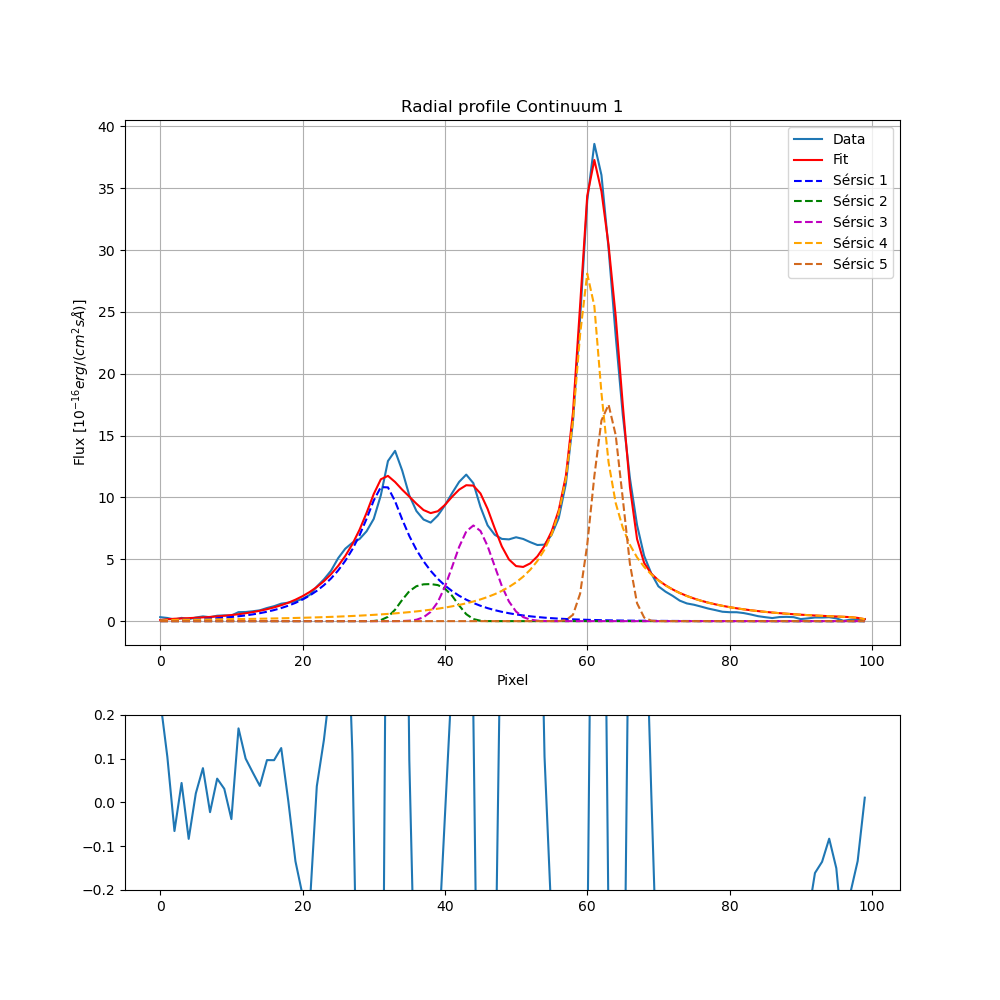

In [59]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [60]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.4799, r_e=10.0000, n=0.9401, x_0=31.4673
Sérsic 2: I_e=2.3206, r_e=3.0000, n=0.2084, x_0=37.7089
Sérsic 3: I_e=4.5607, r_e=3.0000, n=0.4498, x_0=44.0346
Sérsic 4: I_e=1.8863, r_e=12.8447, n=1.6745, x_0=59.8852
Sérsic 5: I_e=11.0830, r_e=2.1090, n=0.4926, x_0=62.8249
[0.89755946 0.52617855 0.11500632 2.0564234  2.34832526 2.56416688
 0.79372698 3.31359809 1.82471465 0.61408124 0.26340064 0.95916304
 0.36186728 1.24892979 0.26328209 0.16833684 4.6239057  0.58162602
 0.32583222 0.88651593]
7.77173833449348


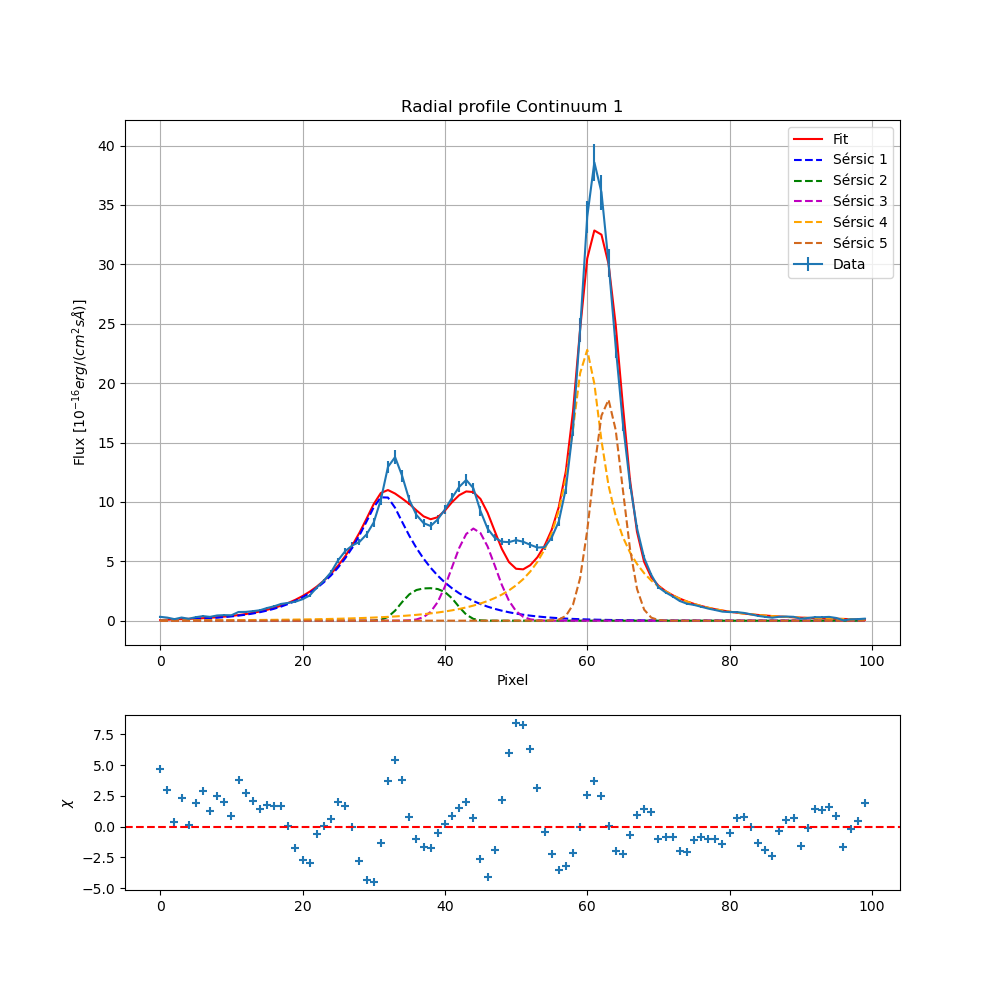

In [61]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

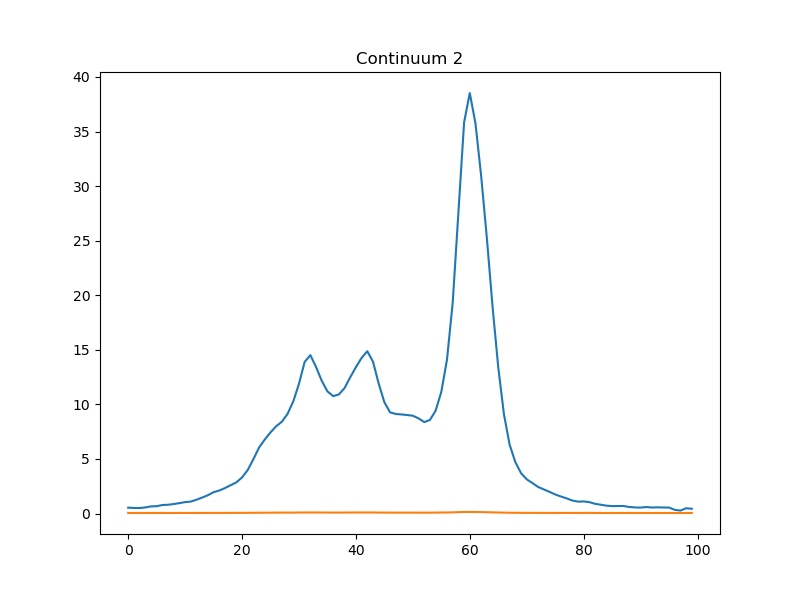

In [11]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [63]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3878.713461066773
differential_evolution step 2: f(x)= 3705.938422085638
differential_evolution step 3: f(x)= 3705.938422085638
differential_evolution step 4: f(x)= 1549.8000922985884
differential_evolution step 5: f(x)= 1549.8000922985884
differential_evolution step 6: f(x)= 1272.0293353667514
differential_evolution step 7: f(x)= 1272.0293353667514
differential_evolution step 8: f(x)= 1272.0293353667514
differential_evolution step 9: f(x)= 1272.0293353667514
differential_evolution step 10: f(x)= 989.7763810805044
differential_evolution step 11: f(x)= 989.7763810805044
differential_evolution step 12: f(x)= 989.7763810805044
differential_evolution step 13: f(x)= 989.7763810805044
differential_evolution step 14: f(x)= 776.2647662096684
differential_evolution step 15: f(x)= 734.5946024868681
differential_evolution step 16: f(x)= 679.6248979418873
differential_evolution step 17: f(x)= 523.5368133945343
differential_evolution step 18: f(x)= 523.536813394

Sérsic 1: I_e=4.0375, r_e=10.0000, n=0.7687, x_0=31.4673
Sérsic 2: I_e=3.5689, r_e=2.6639, n=0.1000, x_0=40.0899
Sérsic 3: I_e=4.7279, r_e=3.0000, n=0.2986, x_0=44.0346
Sérsic 4: I_e=2.2188, r_e=15.1004, n=1.9082, x_0=59.6435
Sérsic 5: I_e=9.3060, r_e=1.5007, n=0.1000, x_0=62.8248


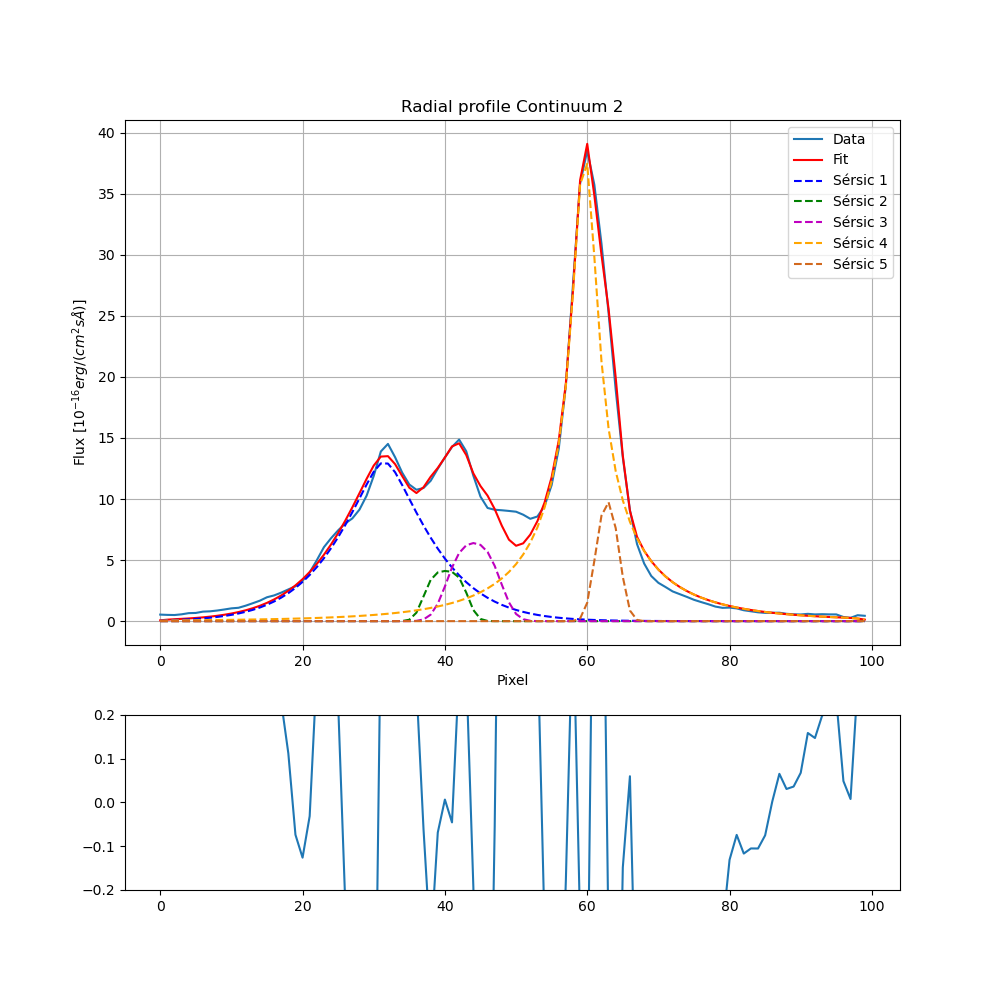

In [64]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [65]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=4.0141, r_e=10.0000, n=0.7795, x_0=31.4152
Sérsic 2: I_e=3.4601, r_e=2.5201, n=0.1006, x_0=40.0401
Sérsic 3: I_e=4.7950, r_e=3.0000, n=0.3189, x_0=44.0346
Sérsic 4: I_e=0.6814, r_e=29.3918, n=2.7332, x_0=58.8324
Sérsic 5: I_e=8.8422, r_e=1.8802, n=0.5394, x_0=62.8248
[ 0.43895977  0.44184221  0.07898792  0.52224974 33.83217109 21.60695566
  2.33638807  1.32578462  3.08926692  3.11704706  0.31743668  5.0089166
  0.22316591  5.93661862  0.29940376  0.24900751  3.92827046  0.48572799
  0.38272192  0.51223754]
10.144887652627109


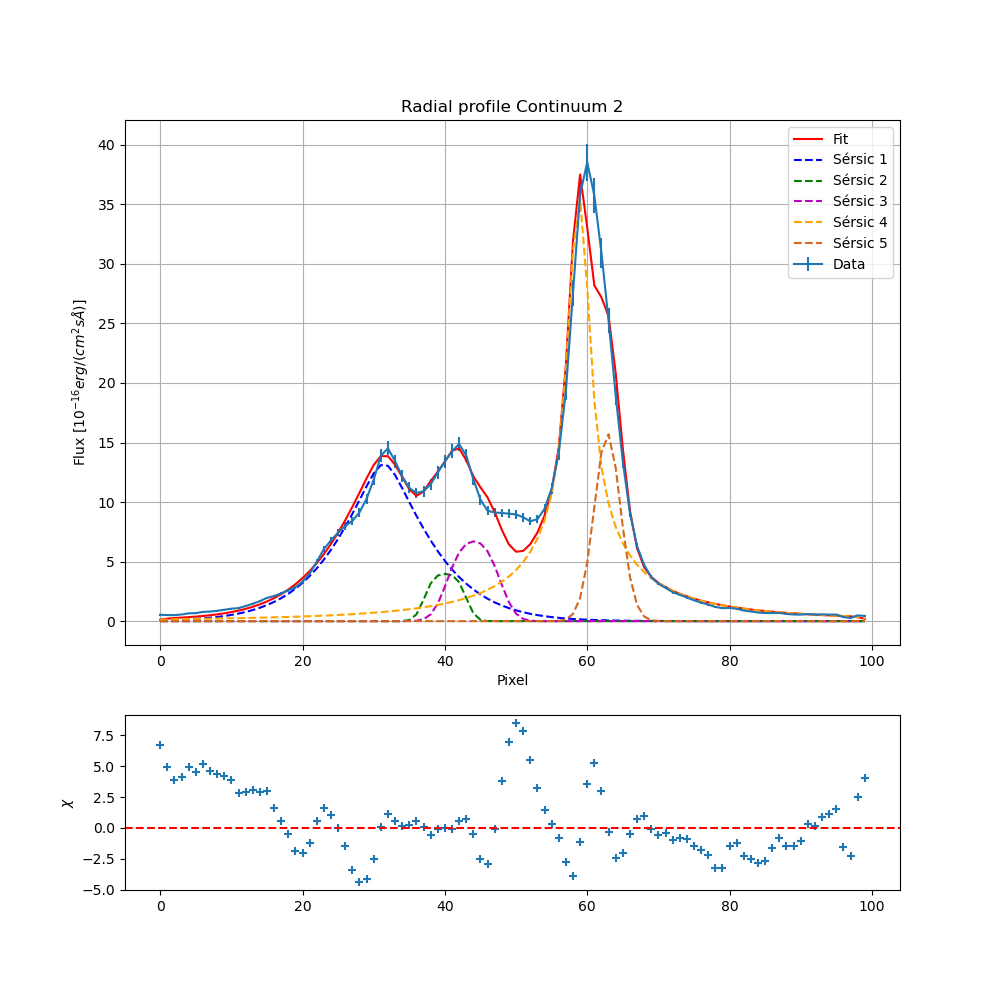

In [66]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

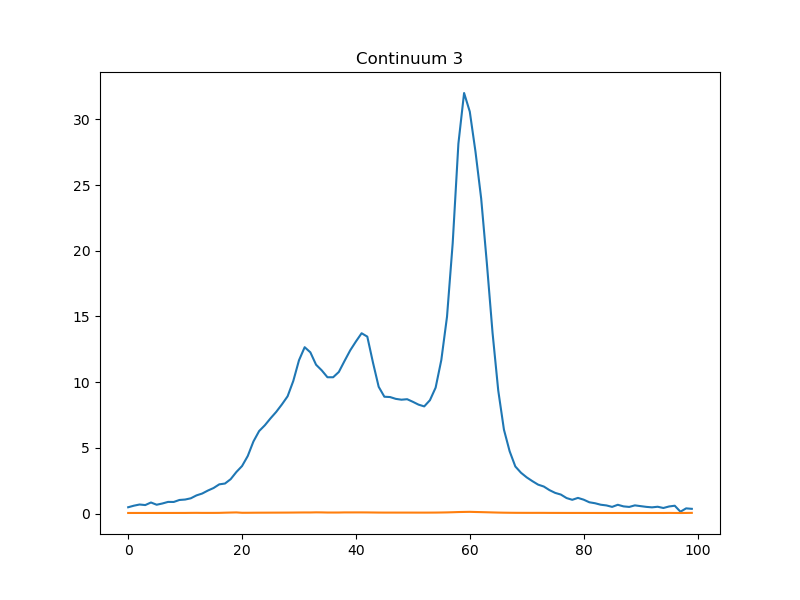

In [67]:
mask_continuum_3 =  (wv > 5950)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [68]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3504.2695624161074
differential_evolution step 2: f(x)= 3504.2695624161074
differential_evolution step 3: f(x)= 3365.2804376781446
differential_evolution step 4: f(x)= 2355.7801782849433
differential_evolution step 5: f(x)= 2355.7801782849433
differential_evolution step 6: f(x)= 2355.7801782849433
differential_evolution step 7: f(x)= 1425.1215678349233
differential_evolution step 8: f(x)= 1382.033351824987
differential_evolution step 9: f(x)= 1096.1349388455726
differential_evolution step 10: f(x)= 1096.1349388455726
differential_evolution step 11: f(x)= 1096.1349388455726
differential_evolution step 12: f(x)= 1096.1349388455726
differential_evolution step 13: f(x)= 1055.1622460075116
differential_evolution step 14: f(x)= 1055.1622460075116
differential_evolution step 15: f(x)= 983.6213420615425
differential_evolution step 16: f(x)= 983.6213420615425
differential_evolution step 17: f(x)= 983.6213420615425
differential_evolution step 18: f(x)= 983.62

Sérsic 1: I_e=4.3946, r_e=10.0000, n=0.6515, x_0=31.4673
Sérsic 2: I_e=3.6360, r_e=2.3424, n=0.1000, x_0=39.7787
Sérsic 3: I_e=4.1260, r_e=3.0000, n=0.2511, x_0=44.0346
Sérsic 4: I_e=2.7764, r_e=12.3794, n=1.6413, x_0=59.2010
Sérsic 5: I_e=6.7191, r_e=1.1951, n=0.1000, x_0=62.8248


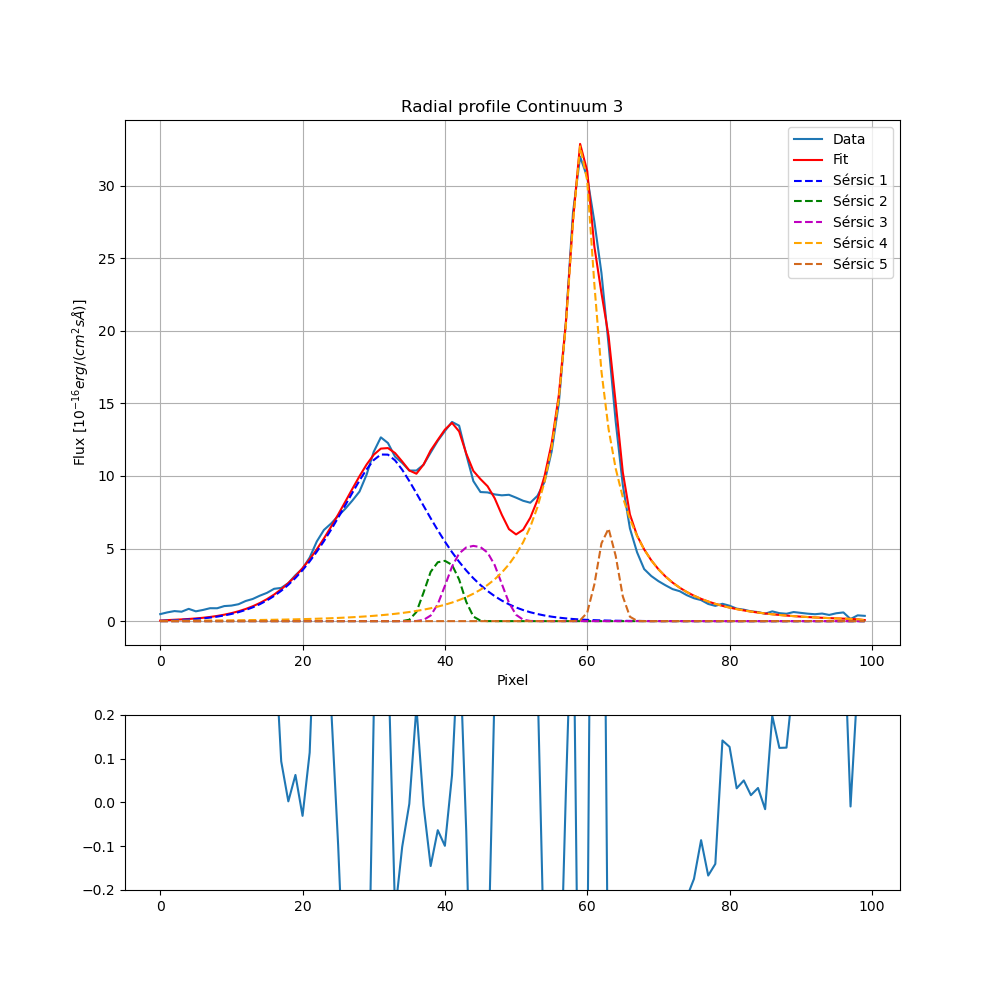

In [69]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [70]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=2.3513, r_e=13.6211, n=1.0092, x_0=30.8353
Sérsic 2: I_e=3.5259, r_e=1.7140, n=0.2462, x_0=40.8516
Sérsic 3: I_e=3.4005, r_e=6.6210, n=0.2864, x_0=43.9305
Sérsic 4: I_e=0.5593, r_e=29.7407, n=2.5732, x_0=58.4353
Sérsic 5: I_e=6.7236, r_e=2.5643, n=0.6901, x_0=61.4381
[0.2715763  0.52822763 0.06143262 0.61916923 2.59563944 0.36445244
 0.66482013 0.35823689 0.57591589 1.13543951 0.13693683 1.04480445
 0.17341185 5.37067069 0.34951992 0.21721259 1.95607172 0.32595497
 0.20391428 0.48508902]
2.8570801045055787


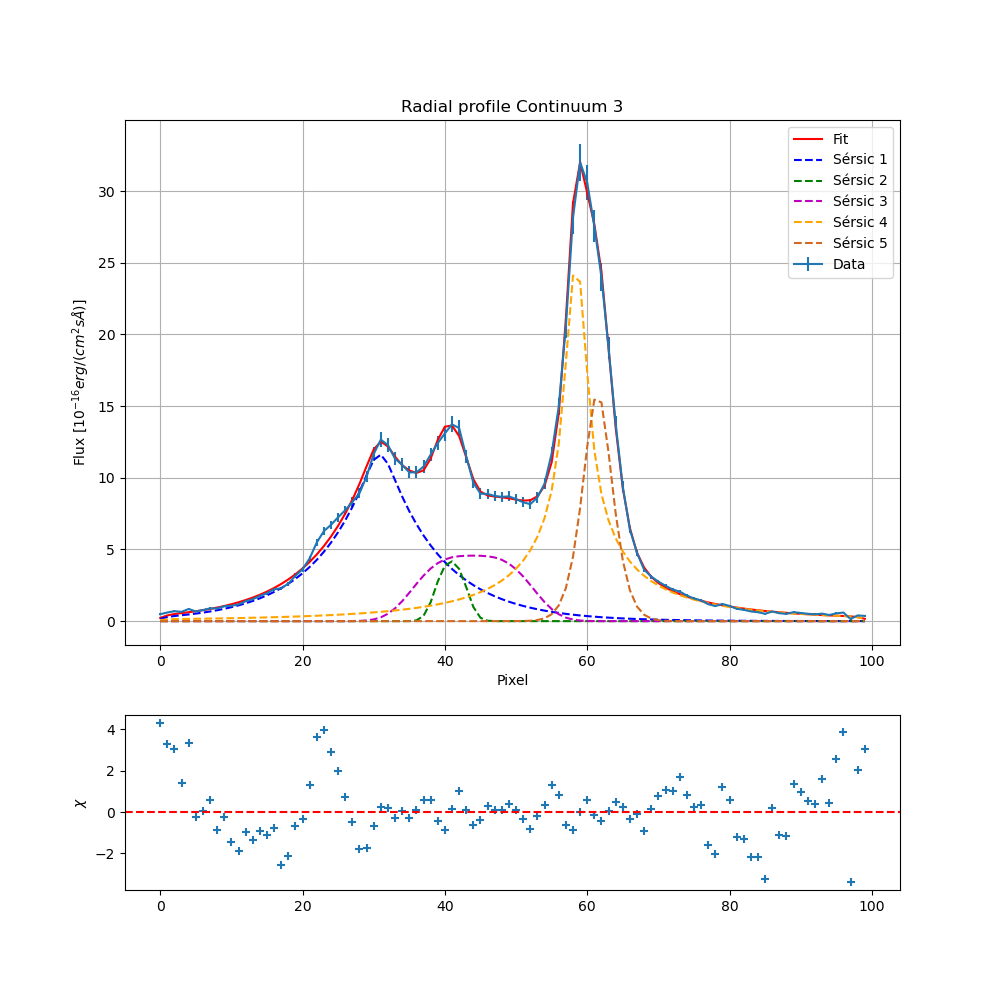

In [71]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [72]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

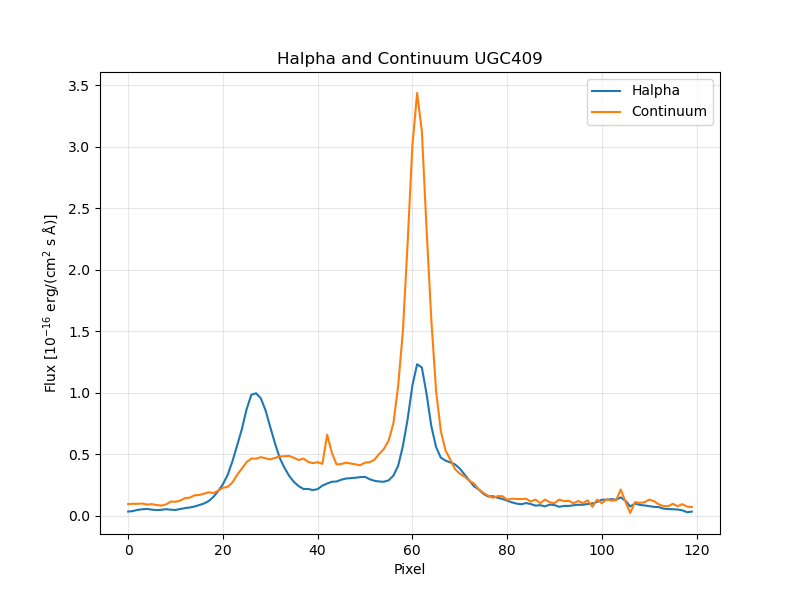

In [75]:
mask_continuum_3 = (wv > 6550)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum UGC409')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_UGC409')